# Étape 4 - Baseline et comparaison de modèles

Cette étape choisit un modèle. Elle ne le mesure pas : l'évaluation finale appartient à
l'étape 5.

**La règle du jeu de test.** Le jeu de test est mis de côté dès la première cellule et
n'est pas touché de tout ce notebook. Toutes les comparaisons se font par validation
croisée à cinq plis **sur le seul jeu d'apprentissage**. Un jeu de test consulté pour
choisir un modèle cesse d'être un jeu de test : il devient un second jeu de validation, et
le score qu'il produit est optimiste.

La démarche est donc : une référence naïve d'abord, cinq modèles concurrents ensuite, un diagnostic de
surapprentissage, puis une décision argumentée.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / 'csv' / 'dataset_phase3_final.csv'
FIGURE_PATH = PROJECT_PATH / 'figures_eda'
FIGURE_PATH.mkdir(exist_ok=True)

TARGET = "6-Taux d'emploi salarié en France - 6 mois après le diplôme"
SORTANTS = '6-Nombre de sortants - 6 mois après le diplôme'
POURSUIVANTS = '6-Nombre de poursuivants - 6 mois après le diplôme'

CATEGORICAL_FEATURES = ['Région', 'Académie', 'Type de diplôme', 'Domaine disciplinaire',
                        'Discipline', 'Secteur disciplinaire', 'Promotion', 'tranche_effectif']
NUMERIC_FEATURES = [SORTANTS, POURSUIVANTS, 'anciennete_promotion',
                    'promotion_choc_sanitaire', 'est_diplome_professionnalisant',
                    'taille_formation', 'ratio_poursuite', 'taille_mediane_secteur',
                    'nb_formations_etablissement', 'part_sortants_etablissement',
                    'nb_etablissements_par_diplome']
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

df = pd.read_csv(DATA_PATH, dtype={'Code du diplôme SISE': str})
X = df[FEATURES]
y = df[TARGET]

# Découpage identique à celui de l'étape 3 : mêmes données, même random_state.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Le jeu de test est mis hors de portée pour toute la durée de ce notebook.
del X_test, y_test

CV = KFold(n_splits=5, shuffle=True, random_state=42)
SCORING = {'mae': 'neg_mean_absolute_error',
           'rmse': 'neg_root_mean_squared_error',
           'r2': 'r2'}

print(f'Apprentissage : {X_train.shape[0]} lignes × {X_train.shape[1]} variables')
print('Jeu de test : mis de côté, non chargé dans ce notebook')
print(f'Validation : {CV.get_n_splits()} plis, random_state=42')

Apprentissage : 13652 lignes × 19 variables
Jeu de test : mis de côté, non chargé dans ce notebook
Validation : 5 plis, random_state=42


## 1. La pipeline

Tout le prétraitement est dans la pipeline. C'est ce qui garantit que l'encodage et la
mise à l'échelle sont réajustés sur les seules données d'entraînement de chaque pli, et
jamais sur les données de validation.

`handle_unknown='ignore'` gère le cas d'une modalité absente d'un pli d'entraînement :
plutôt que d'échouer, l'encodeur produit une ligne de zéros. La mise à l'échelle n'est
appliquée que pour les modèles linéaires, qui en ont besoin ; les arbres n'y sont pas
sensibles.

In [2]:
def creer_pipeline(modele, mettre_a_echelle=False):
    """Assemble le prétraitement et le modèle dans une pipeline unique."""
    traitement_numerique = StandardScaler() if mettre_a_echelle else 'passthrough'
    preprocesseur = ColumnTransformer([
        ('categorielles', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES),
        ('numeriques', traitement_numerique, NUMERIC_FEATURES),
    ])
    return Pipeline([('pretraitement', preprocesseur), ('modele', modele)])


exemple = creer_pipeline(Ridge())
exemple.fit(X_train, y_train)
nb_colonnes = exemple.named_steps['pretraitement'].transform(X_train.head(5)).shape[1]
print(f'{len(FEATURES)} variables en entrée → {nb_colonnes} colonnes après encodage')
exemple

19 variables en entrée → 150 colonnes après encodage


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pretraitement', ...), ('modele', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Région','Académie','Type de diplôme',...,'nb_formations_etablissement', 'part_sortants_etablissement','nb_etablissements_par_diplome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorielles', ...), ('numeriques', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in 

## 2. Référence naïve

Avant de se réjouir d'un score, il faut savoir ce que ferait un modèle qui n'apprend rien.
`DummyRegressor(strategy='mean')` prédit toujours la moyenne de la cible, quelles que
soient les variables.

Deux points de méthode. D'abord, la baseline est évaluée **par la même validation croisée
que les autres modèles** : comparer une baseline calculée d'un côté et des modèles
évalués de l'autre n'a pas de sens. Ensuite, la moyenne est apprise **dans chaque pli**,
sur les données d'entraînement de ce pli, exactement comme les autres modèles.

In [3]:
baseline = cross_validate(creer_pipeline(DummyRegressor(strategy='mean')),
                          X_train, y_train, cv=CV, scoring=SCORING)

MAE_BASELINE = -baseline['test_mae'].mean()
RMSE_BASELINE = -baseline['test_rmse'].mean()

print('Référence naïve (prédire toujours la moyenne) :')
print(f'  MAE  = {MAE_BASELINE:.3f} points de taux')
print(f'  RMSE = {RMSE_BASELINE:.3f} points de taux')
print(f"  R²   = {baseline['test_r2'].mean():.3f}")
print()
print(f"En clair : sans rien apprendre, on se trompe en moyenne de {MAE_BASELINE:.1f} points")
print(f"de taux d'emploi. Tout modèle doit faire mieux que cela pour justifier son existence.")

Référence naïve (prédire toujours la moyenne) :
  MAE  = 14.971 points de taux
  RMSE = 18.455 points de taux
  R²   = -0.001

En clair : sans rien apprendre, on se trompe en moyenne de 15.0 points
de taux d'emploi. Tout modèle doit faire mieux que cela pour justifier son existence.


## 3. Comparaison de six modèles

Six modèles sont comparés dans la même pipeline, sur les mêmes plis, avec les mêmes
métriques :

| Modèle | Ce qu'il apporte à la comparaison |
|---|---|
| `DummyRegressor` | Le plancher : la performance sans apprentissage |
| `LinearRegression` | Le modèle simple exigé, entièrement interprétable |
| `Ridge` | Le même, pénalisé, plus stable face aux 139 colonnes issues de l'encodage |
| `DecisionTreeRegressor` | Un modèle non linéaire, mais seul : il montre la tendance au surapprentissage |
| `RandomForestRegressor` | La moyenne de nombreux arbres : corrige ce défaut |
| `HistGradientBoostingRegressor` | Une seconde approche d'ensemble, par boosting |

`return_train_score=True` permet de mesurer, en plus de la performance, l'écart entre ce
que le modèle fait sur ses données d'entraînement et sur des données qu'il n'a pas vues.

In [4]:
MODELES = {
    'Référence naïve': (DummyRegressor(strategy='mean'), False),
    'Régression linéaire': (LinearRegression(), True),
    'Ridge (alpha=1)': (Ridge(alpha=1.0), True),
    'Arbre de décision': (DecisionTreeRegressor(random_state=42), False),
    'Forêt aléatoire': (RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                              random_state=42, n_jobs=-1), False),
    'Gradient boosting': (HistGradientBoostingRegressor(random_state=42), False),
}

resultats = []
for nom, (modele, mettre_a_echelle) in MODELES.items():
    scores = cross_validate(creer_pipeline(modele, mettre_a_echelle), X_train, y_train,
                            cv=CV, scoring=SCORING, return_train_score=True, n_jobs=1)
    resultats.append({
        'modèle': nom,
        'MAE': round(-scores['test_mae'].mean(), 3),
        'MAE (écart-type)': round(scores['test_mae'].std(), 3),
        'RMSE': round(-scores['test_rmse'].mean(), 3),
        'R²': round(scores['test_r2'].mean(), 3),
        'R² (écart-type)': round(scores['test_r2'].std(), 3),
        'R² entraînement': round(scores['train_r2'].mean(), 3),
        'temps (s)': round(scores['fit_time'].mean(), 2),
    })

comparaison = pd.DataFrame(resultats).set_index('modèle')
comparaison['gain MAE vs naïve'] = (MAE_BASELINE - comparaison['MAE']).round(3)
comparaison['écart train − validation (R²)'] = (
    comparaison['R² entraînement'] - comparaison['R²']).round(3)
comparaison.sort_values('MAE')

,MAE,MAE (écart-type),RMSE,R²,R² (écart-type),R² entraînement,temps (s),gain MAE vs naïve,écart train − validation (R²)
modèle,,,,,,,,,
Forêt aléatoire,9.495,0.147,12.365,0.550,0.018,0.899,2.18,5.476,0.349
Gradient boosting,9.518,0.124,12.362,0.551,0.014,0.653,0.43,5.453,0.102
Ridge (alpha=1),10.411,0.168,13.451,0.468,0.020,0.479,0.06,4.560,0.011
Régression linéaire,10.414,0.170,13.458,0.468,0.020,0.480,0.13,4.557,0.012
Arbre de décision,13.168,0.100,17.321,0.118,0.029,1.000,0.16,1.803,0.882
Référence naïve,14.971,0.159,18.455,-0.001,0.001,0.000,0.03,0.000,0.001


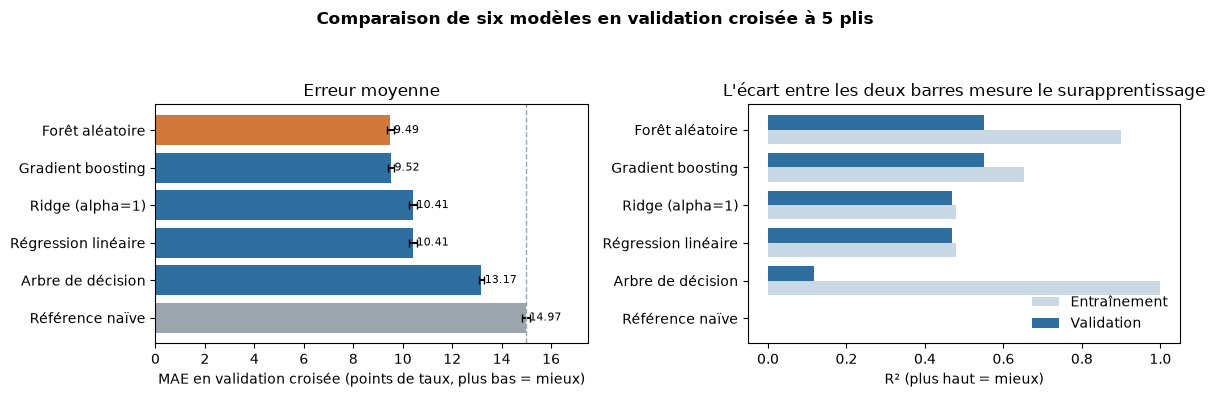

In [5]:
ordre = comparaison.sort_values('MAE', ascending=False)
positions = np.arange(len(ordre))

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

couleurs = ['#9aa5ad' if nom == 'Référence naïve' else
            ('#d1793c' if nom == ordre['MAE'].idxmin() else '#2f6f9f') for nom in ordre.index]
axes[0].barh(positions, ordre['MAE'], xerr=ordre['MAE (écart-type)'],
             color=couleurs, capsize=3)
axes[0].set_yticks(positions)
axes[0].set_yticklabels(ordre.index)
axes[0].axvline(MAE_BASELINE, color='#9aa5ad', linestyle='--', linewidth=1)
axes[0].set_xlabel('MAE en validation croisée (points de taux, plus bas = mieux)')
axes[0].set_title('Erreur moyenne')
for position, valeur in enumerate(ordre['MAE']):
    axes[0].text(valeur + 0.15, position, f'{valeur:.2f}', va='center', fontsize=8)
axes[0].set_xlim(0, ordre['MAE'].max() + 2.5)

largeur = 0.38
axes[1].barh(positions - largeur / 2, ordre['R² entraînement'], height=largeur,
             color='#c8d8e4', label='Entraînement')
axes[1].barh(positions + largeur / 2, ordre['R²'], height=largeur,
             color='#2f6f9f', label='Validation')
axes[1].set_yticks(positions)
axes[1].set_yticklabels(ordre.index)
axes[1].set_xlabel('R² (plus haut = mieux)')
axes[1].set_title("L'écart entre les deux barres mesure le surapprentissage")
axes[1].legend(frameon=False, loc='lower right')

figure.suptitle('Comparaison de six modèles en validation croisée à 5 plis',
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.92))
plt.savefig(FIGURE_PATH / 'fig12_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Diagnostic de surapprentissage

Un écart de R² ne parle pas. On le traduit en deux grandeurs concrètes : la dégradation en
points de taux d'emploi, et le nombre de formations sur lesquelles le modèle se trompe de
plus de 15 points, c'est-à-dire au-delà de ce qu'un utilisateur accepterait.

In [6]:
SEUIL_ERREUR_GRAVE = 15

diagnostic = []
for nom, (modele, mettre_a_echelle) in MODELES.items():
    scores = cross_validate(creer_pipeline(modele, mettre_a_echelle), X_train, y_train,
                            cv=CV, scoring={'mae': 'neg_mean_absolute_error'},
                            return_train_score=True, n_jobs=1)
    mae_train = -scores['train_mae'].mean()
    mae_validation = -scores['test_mae'].mean()
    diagnostic.append({
        'modèle': nom,
        'MAE entraînement': round(mae_train, 3),
        'MAE validation': round(mae_validation, 3),
        'dégradation (points)': round(mae_validation - mae_train, 3),
        # Le ratio n'a de sens que si l'erreur d'entraînement n'est pas quasi nulle :
        # un arbre non élagué mémorise ses données et produirait un pourcentage absurde.
        'dégradation (%)': (round(100 * (mae_validation - mae_train) / mae_train, 1)
                            if mae_train > 0.5 else np.nan),
    })
diagnostic = pd.DataFrame(diagnostic).set_index('modèle')
diagnostic

,MAE entraînement,MAE validation,dégradation (points),dégradation (%)
modèle,,,,
Référence naïve,14.970,14.971,0.002,0.0
Régression linéaire,10.312,10.414,0.102,1.0
Ridge (alpha=1),10.315,10.411,0.096,0.9
Arbre de décision,0.006,13.168,13.162,NaN
Forêt aléatoire,4.334,9.495,5.161,119.1
Gradient boosting,8.390,9.518,1.128,13.4


In [7]:
from sklearn.model_selection import cross_val_predict

# Traduction en nombre de formations : combien de lignes le modèle rate-t-il vraiment ?
volumes = []
for nom in ['Référence naïve', 'Ridge (alpha=1)', 'Forêt aléatoire', 'Gradient boosting']:
    modele, mettre_a_echelle = MODELES[nom]
    predictions = cross_val_predict(creer_pipeline(modele, mettre_a_echelle),
                                    X_train, y_train, cv=CV, n_jobs=1)
    erreurs = np.abs(y_train.to_numpy() - predictions)
    volumes.append({
        'modèle': nom,
        f'erreur > {SEUIL_ERREUR_GRAVE} pts': int((erreurs > SEUIL_ERREUR_GRAVE).sum()),
        'part (%)': round(100 * (erreurs > SEUIL_ERREUR_GRAVE).mean(), 1),
        'erreur > 25 pts': int((erreurs > 25).sum()),
        'erreur médiane (pts)': round(float(np.median(erreurs)), 2),
    })
volumes = pd.DataFrame(volumes).set_index('modèle')

reference = volumes.loc['Référence naïve', f'erreur > {SEUIL_ERREUR_GRAVE} pts']
meilleur = volumes.loc['Forêt aléatoire', f'erreur > {SEUIL_ERREUR_GRAVE} pts']
print(f'Sur les {len(y_train)} formations du jeu d\'apprentissage, en validation croisée :')
print(f"  · la référence naïve rate {reference} formations de plus de "
      f'{SEUIL_ERREUR_GRAVE} points')
print(f'  · la forêt aléatoire en rate {meilleur}, soit {reference - meilleur} de moins '
      f'({100 * (reference - meilleur) / reference:.0f} % de réduction)')
volumes

Sur les 13652 formations du jeu d'apprentissage, en validation croisée :
  · la référence naïve rate 5940 formations de plus de 15 points
  · la forêt aléatoire en rate 2853, soit 3087 de moins (52 % de réduction)


,erreur > 15 pts,part (%),erreur > 25 pts,erreur médiane (pts)
modèle,,,,
Référence naïve,5940,43.5,2551,13.01
Ridge (alpha=1),3318,24.3,905,8.39
Forêt aléatoire,2853,20.9,656,7.55
Gradient boosting,2771,20.3,667,7.58


## 5. Les variables créées à l'étape 3 servent-elles vraiment ?

La grille demande des features « pertinentes pour la prédiction ». La seule façon
honnête de le vérifier est de mesurer le modèle avec et sans elles, dans les mêmes
conditions.

In [8]:
FEATURES_BRUTES = ['Région', 'Académie', 'Type de diplôme', 'Domaine disciplinaire',
                   'Discipline', 'Secteur disciplinaire', 'Promotion',
                   SORTANTS, POURSUIVANTS]
FEATURES_CREEES = [colonne for colonne in FEATURES if colonne not in FEATURES_BRUTES]


def creer_pipeline_restreint(modele, categorielles, numeriques):
    preprocesseur = ColumnTransformer([
        ('categorielles', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorielles),
        ('numeriques', 'passthrough', numeriques),
    ])
    return Pipeline([('pretraitement', preprocesseur), ('modele', modele)])


foret = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1)
perimetres = {
    'Variables brutes seules': (
        [c for c in FEATURES_BRUTES if c in CATEGORICAL_FEATURES],
        [c for c in FEATURES_BRUTES if c in NUMERIC_FEATURES]),
    'Brutes + 10 variables créées': (CATEGORICAL_FEATURES, NUMERIC_FEATURES),
}

apport = []
for nom, (categorielles, numeriques) in perimetres.items():
    scores = cross_validate(creer_pipeline_restreint(foret, categorielles, numeriques),
                            X_train[categorielles + numeriques], y_train,
                            cv=CV, scoring=SCORING, n_jobs=1)
    apport.append({'périmètre': nom, 'variables': len(categorielles) + len(numeriques),
                   'MAE': round(-scores['test_mae'].mean(), 3),
                   'RMSE': round(-scores['test_rmse'].mean(), 3),
                   'R²': round(scores['test_r2'].mean(), 3)})
apport = pd.DataFrame(apport).set_index('périmètre')

gain_mae = apport['MAE'].iloc[0] - apport['MAE'].iloc[1]
gain_r2 = apport['R²'].iloc[1] - apport['R²'].iloc[0]
print(f'Apport des variables créées : {gain_mae:+.3f} point de MAE, {gain_r2:+.3f} de R²')
apport

Apport des variables créées : +0.488 point de MAE, +0.051 de R²


,variables,MAE,RMSE,R²
périmètre,,,,
Variables brutes seules,9,9.983,13.049,0.499
Brutes + 10 variables créées,19,9.495,12.365,0.550


## 6. La seconde source apporte-t-elle quelque chose au modèle ?

L'étape 1 a chargé un second jeu, le référentiel des établissements, et l'a laissé hors du
modèle : 20 % des lignes n'y trouvent pas d'établissement, et décider de leur sort est une
question de modélisation, pas de chargement. Elle se tranche ici, au même endroit et avec
le même protocole que les variables créées à l'étape 3.

Le traitement des non-appariés est explicite. Côté catégoriel, ils forment une modalité
`non référencé` : c'est une information en soi, puisque le référentiel ne recense que les
établissements principaux. Côté numérique, l'effectif d'inscrits est imputé par la médiane
**à l'intérieur de la pipeline**, donc réajusté sur les seules données d'entraînement de
chaque pli, avec un indicateur de valeur manquante.

In [9]:
import json
import urllib.request

from sklearn.impute import SimpleImputer

REFERENTIEL_URL = (
    'https://data.enseignementsup-recherche.gouv.fr/api/explore/v2.1/catalog/'
    'datasets/fr-esr-principaux-etablissements-enseignement-superieur/exports/json')
REFERENTIEL_PATH = PROJECT_PATH / 'csv' / 'referentiel_etablissements.json'
CODE_UAI = "Code UAI de l'établissement"

if not REFERENTIEL_PATH.exists():
    urllib.request.urlretrieve(REFERENTIEL_URL, REFERENTIEL_PATH)
with open(REFERENTIEL_PATH, encoding='utf-8') as fichier:
    referentiel = pd.json_normalize(json.load(fichier))

etablissements = pd.DataFrame({
    CODE_UAI: referentiel['uai'],
    'secteur_etablissement': referentiel['secteur_d_etablissement'],
    'statut_juridique_etablissement': referentiel['statut_juridique_court'],
    'type_etablissement': referentiel['type_d_etablissement'].apply(
        lambda valeur: valeur[0] if isinstance(valeur, list) and valeur else None),
    'inscrits_etablissement': referentiel['inscrits_2022'],
})

CAT_REFERENTIEL = ['secteur_etablissement', 'statut_juridique_etablissement',
                   'type_etablissement']
NUM_REFERENTIEL = ['inscrits_etablissement']

enrichi = df.merge(etablissements, on=CODE_UAI, how='left')
assert len(enrichi) == len(df), 'La jointure a dupliqué des lignes'
enrichi[CAT_REFERENTIEL] = enrichi[CAT_REFERENTIEL].fillna('non référencé')

# Le découpage est refait à l'identique sur le jeu enrichi, et l'égalité des cibles
# prouve que les lignes d'apprentissage sont exactement les mêmes qu'au reste du notebook.
X_enrichi = enrichi[FEATURES + CAT_REFERENTIEL + NUM_REFERENTIEL]
X_train_enrichi, _, y_train_controle, _ = train_test_split(
    X_enrichi, y, test_size=0.20, random_state=42)
assert y_train_controle.equals(y_train), 'Le découpage enrichi ne correspond pas'
del _

print(f'Lignes appariées au référentiel : '
      f'{100 * (enrichi["secteur_etablissement"] != "non référencé").mean():.1f} %')
print(f'Effectif d\'inscrits manquant : '
      f'{100 * enrichi["inscrits_etablissement"].isna().mean():.1f} % des lignes')
print()


def creer_pipeline_enrichi(modele):
    """Même pipeline, plus les variables du référentiel et l'imputation de l'effectif."""
    preprocesseur = ColumnTransformer([
        ('categorielles', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES + CAT_REFERENTIEL),
        ('numeriques', 'passthrough', NUMERIC_FEATURES),
        ('numeriques_referentiel',
         SimpleImputer(strategy='median', add_indicator=True), NUM_REFERENTIEL),
    ])
    return Pipeline([('pretraitement', preprocesseur), ('modele', modele)])


scores = cross_validate(creer_pipeline_enrichi(foret), X_train_enrichi, y_train,
                        cv=CV, scoring=SCORING, n_jobs=1)
comparaison_referentiel = pd.concat([apport, pd.DataFrame([{
    'périmètre': '+ 4 variables du référentiel',
    'variables': X_train_enrichi.shape[1],
    'MAE': round(-scores['test_mae'].mean(), 3),
    'RMSE': round(-scores['test_rmse'].mean(), 3),
    'R²': round(scores['test_r2'].mean(), 3),
}]).set_index('périmètre')])

gain_mae = comparaison_referentiel['MAE'].iloc[1] - comparaison_referentiel['MAE'].iloc[2]
gain_r2 = comparaison_referentiel['R²'].iloc[2] - comparaison_referentiel['R²'].iloc[1]
dispersion = -scores['test_mae']

print(f'Apport de la seconde source : {gain_mae:+.3f} point de MAE, {gain_r2:+.3f} de R²')
print(f'MAE par pli : {", ".join(f"{valeur:.3f}" for valeur in dispersion)}')
print(f'Écart-type entre plis : {dispersion.std():.3f} point, soit '
      f'{dispersion.std() / abs(gain_mae):.0f} fois le gain mesuré')
comparaison_referentiel

Lignes appariées au référentiel : 79.7 %
Effectif d'inscrits manquant : 26.3 % des lignes



Apport de la seconde source : +0.020 point de MAE, +0.003 de R²
MAE par pli : 9.330, 9.513, 9.676, 9.503, 9.355
Écart-type entre plis : 0.125 point, soit 6 fois le gain mesuré


,variables,MAE,RMSE,R²
périmètre,,,,
Variables brutes seules,9,9.983,13.049,0.499
Brutes + 10 variables créées,19,9.495,12.365,0.550
+ 4 variables du référentiel,23,9.475,12.331,0.553


**La seconde source n'apporte rien de mesurable au modèle.** 0,020 point de MAE gagné,
quand la MAE varie de 0,125 point d'un pli de validation à l'autre : le gain est **six fois
plus petit que le bruit** de la validation croisée. À comparer aux 0,488 point apportés par
les dix variables créées à l'étape 3, mesurés avec le même protocole, sur le même
découpage, avec le même modèle.

**L'explication la plus plausible : l'information est déjà là, sous une autre forme.** Le
référentiel décrit l'établissement, or le modèle dispose déjà de son académie, de sa région
et de son nombre de formations. Le clivage public / privé relevé à l'étape 1, 4,5 points
d'écart de taux d'emploi, est réel mais probablement redondant avec la discipline et le
type de diplôme : une école de commerce privée et une université ne délivrent pas les mêmes
diplômes. La variable ne semble pas ajouter d'information, elle en reformule une.

**Décision : les quatre variables ne sont pas retenues.** Le modèle final reste celui des
19 variables, et l'étape 5 n'est pas modifiée.

C'est un résultat négatif, et il est reporté comme tel. Ajouter une source n'améliore pas
mécaniquement un modèle, et le mesurer valait mieux que de gonfler le périmètre pour
l'affichage : les 23 variables auraient donné un tableau plus fourni et un modèle
strictement équivalent. La jointure garde son intérêt en analyse, où l'écart public / privé
est un résultat en soi, et la démarche reste la bonne : charger, mesurer, décider.

## 7. Décision et justification

Le choix ne se fait pas sur le seul meilleur chiffre. Trois critères sont pesés.

**Performance.** Les deux modèles d'ensemble se détachent nettement : 9,50 de MAE contre
10,41 pour les modèles linéaires et 14,97 pour la référence naïve. L'écart entre linéaire
et ensemble indique que la relation n'est pas additive : l'effet d'un secteur
disciplinaire dépend du type de diplôme, et une régression linéaire ne peut pas
représenter cela. Ridge et régression linéaire donnent exactement le même score, ce qui
signifie que la pénalisation ne sert à rien ici : avec 13 652 lignes pour 150 colonnes, il
n'y a pas d'instabilité à corriger.

**Stabilité.** Forêt aléatoire et gradient boosting sont **à égalité** : 9,495 contre
9,518 de MAE, pour un écart-type entre plis de 0,15. L'écart de 0,02 point est vingt fois
plus petit que la variabilité entre plis : il ne signifie rien. Le choix ne peut donc pas
se faire sur le score.

**Diagnostic de surapprentissage.** L'arbre de décision seul est le contre-exemple utile :
R² d'entraînement de 1,000 pour 0,118 en validation, et une MAE d'entraînement de 0,006
point. Il a appris ses données par cœur. La forêt corrige largement ce défaut en moyennant
des arbres entraînés sur des sous-échantillons, mais elle conserve un écart notable
(0,899 contre 0,550 de R², soit 5,2 points de MAE), là où le gradient boosting ne perd que
0,10 de R². Sur ce critère, **le gradient boosting généralise mieux**.

**Modèle retenu : la forêt aléatoire.** Le score ne départage pas les deux modèles
d'ensemble ; la décision se prend donc sur d'autres critères. La forêt expose une
importance des variables directement lisible, qui est exploitée à l'étape 5 pour relier le
modèle aux constats de l'EDA, et elle a moins d'hyperparamètres critiques à régler.

Il faut assumer ce que cela coûte : le gradient boosting est cinq fois plus rapide à
entraîner et surapprend nettement moins. Il reste l'alternative à citer en soutenance, et
l'écart d'entraînement de la forêt est précisément ce que la recherche d'hyperparamètres
de l'étape 5 va tenter de réduire via `min_samples_leaf`.

**Ce que cette étape ne dit pas.** Aucun des chiffres ci-dessus n'est le score du modèle.
Ce sont des scores de validation, obtenus sur des données ayant servi à choisir. Le score
honnête sera mesuré à l'étape 5, une seule fois, sur le jeu de test resté fermé.

## Utilisation de l'IA sur cette étape

| Prompt utilisé | Ce que l'IA a produit | Vérification effectuée |
|---|---|---|
| « Comment comparer plusieurs modèles sklearn proprement ? » | `cross_validate` avec un dictionnaire de scoring | Ajout de `return_train_score=True`, absent de la proposition, sans lequel le surapprentissage est invisible |
| « Ma baseline doit-elle être calculée sur le test ou sur le train ? » | Sur le train, en validation croisée | Recodée avec `DummyRegressor` dans la même pipeline et les mêmes plis que les autres modèles |
| « Comment savoir si mes features servent ? » | Suggestion de regarder `feature_importances_` | Insuffisant : l'importance classe les variables mais ne dit pas si le modèle est meilleur. Remplacé par une comparaison avec et sans, à conditions identiques |
| « Explique-moi l'écart entre R² train et R² validation » | Explication générale du surapprentissage | Traduit en une mesure exploitable : nombre de formations ratées de plus de 15 points |

Le troisième échange est le plus instructif : la réponse de l'IA était correcte mais
répondait à une autre question. L'importance des variables dit *ce que le modèle utilise*,
pas *si le modèle est meilleur*.